In [94]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm
from windrose import WindroseAxes
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

## DPW Supervised Learning

In [95]:
dpw_final = pd.read_csv("final PM data/dpw_final_pm25.csv")
dpw_final = dpw_final.sort_values("datetime_utc").reset_index(drop=True)
dpw_final.head()

,datetime_utc,rh,temp,pm25,ws,wd,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,58.840000,4.361667,0.494283,9.30,270.0,9.300000,1.708382e-15,6,1.000000,6.123234e-17,0.399550,0.464817,0.442483,0.841567,0
1,2025-01-02 07:00:00+00:00,55.430000,4.113333,0.694683,5.60,260.0,5.514923,9.724298e-01,7,0.965926,-2.588190e-01,0.494283,0.399550,0.464817,0.478867,0
2,2025-01-02 08:00:00+00:00,52.586667,3.908333,0.886617,5.70,280.0,5.613404,-9.897946e-01,8,0.866025,-5.000000e-01,0.694683,0.494283,0.399550,0.458833,0
3,2025-01-02 09:00:00+00:00,50.208333,3.943333,0.952167,7.20,290.0,6.765787,-2.462545e+00,9,0.707107,-7.071068e-01,0.886617,0.694683,0.494283,0.442483,0
4,2025-01-02 10:00:00+00:00,49.291667,4.011667,0.969433,4.45,260.0,4.382395,7.727344e-01,10,0.500000,-8.660254e-01,0.952167,0.886617,0.694683,0.464817,0


In [96]:
#define 7 hour gap so as to not "leak" data between train/validation/testing
gap = 7
n = len(dpw_final)

#we segment full time series data into train/valid/test sets quarterly with proper gaps
#allows proper spread of data so that train/valid/test are not limited to certain areas in the time series
train_size = int(.15 * n)
val_size = int(.05 * n)
test_size = int(.05 * n)

#lists of dataframes
train_dfs = []
val_dfs = []
test_dfs = []
start = 0

#loop through data 4 times
for i in range(4):
    train_start = start
    train_end = train_start + train_size

    val_start = train_end + gap
    val_end = val_start + val_size

    test_start = val_end + gap
    test_end = test_start + test_size

    #break loop if out of data
    if test_end > n:
        break

    #add dataframes to list
    train_dfs.append(dpw_final.iloc[train_start:train_end])
    val_dfs.append(dpw_final.iloc[val_start:val_end])
    test_dfs.append(dpw_final.iloc[test_start:test_end])

    #define new "start"
    start = test_end + gap

#concatenate full dataframe
train_df = pd.concat(train_dfs)
val_df = pd.concat(val_dfs)
test_df = pd.concat(test_dfs)

features = [
    "wind_u", "wind_v",
    "pm_lag6", "pm_lag3", "pm_lag2", "pm_lag1",
    "hour_sin", "hour_cos",
    "rh"
]

#define train, test, validation arrays
X_train = train_df[features].values
Y_train = train_df["pm25_bin"].values

X_val = val_df[features].values
Y_val = val_df["pm25_bin"].values

X_test = test_df[features].values
Y_test = test_df["pm25_bin"].values

#create tensor objects
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_val = torch.tensor(Y_val, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [97]:
input_dim = len(features)
torch.manual_seed(8)
#define neural network
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 5)
        )
    
    def forward(self, x):
        return self.model(x)

model = NN()

#utilize cross entropy loss here
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = .001)

In [98]:
#epochs based on observation of validation accuracy
epochs = 1000

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = loss_function(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    #calculate validation accuracy
    with torch.no_grad():
        val_outputs = model(X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (val_predictions == Y_val).float().mean()

    #print to check validation accuracy
    if (epoch) % 100 == 0:
        epoch_s = "Epoch: " + str(epoch) + " "
        loss_s = "Loss: " + str(loss.item()) + " "
        valid_s = "Validation Accuracy: " + str(float(val_accuracy))
        print(epoch_s + loss_s + valid_s)

Epoch: 0 Loss: 2.027977705001831 Validation Accuracy: 0.22357723116874695
Epoch: 100 Loss: 1.0927507877349854 Validation Accuracy: 0.46883469820022583
Epoch: 200 Loss: 0.9403782486915588 Validation Accuracy: 0.5514904856681824
Epoch: 300 Loss: 0.8311679363250732 Validation Accuracy: 0.5934959053993225
Epoch: 400 Loss: 0.7553150057792664 Validation Accuracy: 0.6395664215087891
Epoch: 500 Loss: 0.7000680565834045 Validation Accuracy: 0.6720867156982422
Epoch: 600 Loss: 0.6700083613395691 Validation Accuracy: 0.6978319883346558
Epoch: 700 Loss: 0.6541333794593811 Validation Accuracy: 0.7032520174980164
Epoch: 800 Loss: 0.6425758600234985 Validation Accuracy: 0.7046070694923401
Epoch: 900 Loss: 0.6328185796737671 Validation Accuracy: 0.6883468627929688


In [99]:
test_outputs = model(X_test)
#select bin with highest probability
test_preds = torch.argmax(test_outputs, dim=1)

test_acc = (test_preds == Y_test).float().mean()
print("Final Test Accuracy " + str(test_acc.item()))

Final Test Accuracy 0.7452574372291565


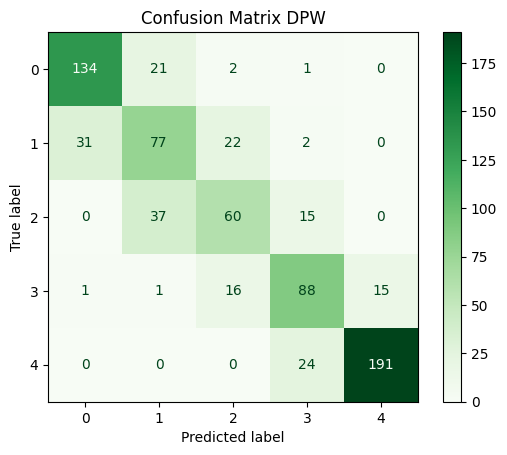

In [100]:
#create confusion matrix for outputs
cm = confusion_matrix(Y_test.numpy(), test_preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix DPW")

plt.savefig("supervised plots/DPW confusion matrix.png")
plt.show()

In [101]:
#produce precision, recall and f1 scores for each bin
print(classification_report(Y_test.numpy(), test_preds.numpy()))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       158
           1       0.57      0.58      0.57       132
           2       0.60      0.54      0.57       112
           3       0.68      0.73      0.70       121
           4       0.93      0.89      0.91       215

    accuracy                           0.75       738
   macro avg       0.72      0.72      0.72       738
weighted avg       0.75      0.75      0.75       738



In [102]:
#function that randomly permutates one feature and measures drop off in model performance
def permutation_importance(model, X, y):
    model.eval()
    
    #evaluate baseline accuracy
    with torch.no_grad():
        baseline_preds = torch.argmax(model(X), dim=1)
        baseline_accuracy = (baseline_preds == y).float().mean()
    
    accuracy_differences = []
    
    for i in range(X.shape[1]):
        X_permuted = X.clone()
        
        #shuffle feature and run model
        idx = torch.randperm(X.shape[0])
        X_permuted[:, i] = X_permuted[idx, i]
        
        with torch.no_grad():
            preds = torch.argmax(model(X_permuted), dim=1)
            accuracy = (preds == y).float().mean()
        
        accuracy_difference = baseline_accuracy - accuracy
        accuracy_differences.append(accuracy_difference.item())
    
    return accuracy_differences

accuracy_differences = permutation_importance(model, X_test, Y_test)

for f, acc_d in zip(features, accuracy_differences):
    print(f, acc_d)

wind_u 0.00270998477935791
wind_v 0.021680176258087158
pm_lag6 0.02303522825241089
pm_lag3 0.0257452130317688
pm_lag2 0.036585330963134766
pm_lag1 0.5528454780578613
hour_sin 0.0
hour_cos -0.004065036773681641
rh 0.0257452130317688


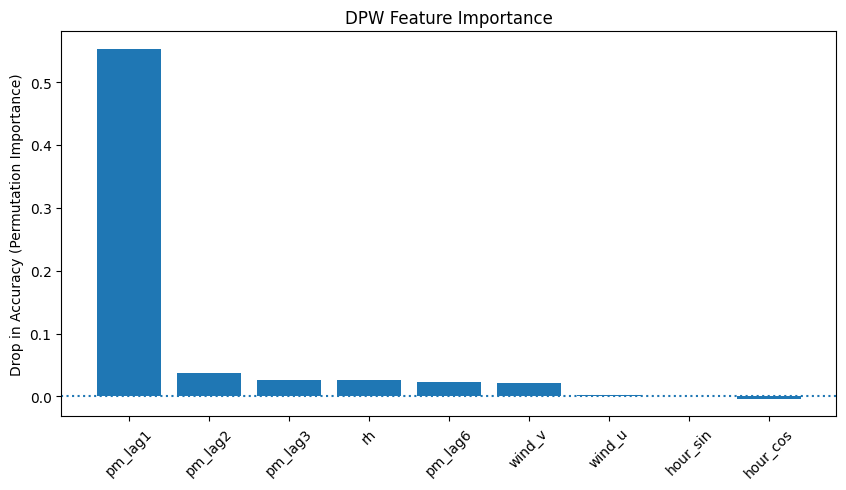

In [103]:
#plot feature importance
importance_dict = dict(zip(features, accuracy_differences))
sorted_items = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("DPW Feature Importance")

plt.axhline(y=0, linestyle=":")

plt.savefig("supervised plots/DPW feature importance full.png")
plt.show()

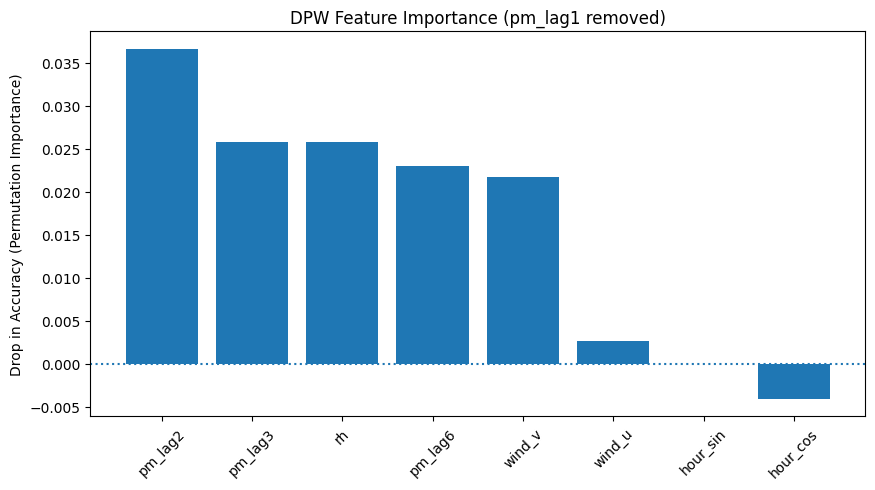

In [104]:
importance_dict = dict(zip(features, accuracy_differences))
#remove pm_lag1 to see other features better
sorted_items = sorted([(f, v) for f, v in importance_dict.items() if f != "pm_lag1"], key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("DPW Feature Importance (pm_lag1 removed)")

plt.axhline(y=0, linestyle=":")

plt.savefig("supervised plots/DPW feature importance pm_lag1 removed.png")
plt.show()

## PEMA Supervised Learning

In [105]:
pema_final = pd.read_csv("final PM data/pema_final_pm25.csv")
pema_final = pema_final.sort_values("datetime_utc").reset_index(drop=True)
pema_final.head()

,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,61.271667,3.978333,288.680000,4.513833,0.045150,4.276054,-1.445701,6,1.000000,6.123234e-17,0.040767,0.049150,0.033750,0.096833,0
1,2025-01-02 07:00:00+00:00,57.641667,3.725000,289.245000,5.204833,0.052300,4.913976,-1.715556,7,0.965926,-2.588190e-01,0.045150,0.040767,0.049150,0.050633,0
2,2025-01-02 08:00:00+00:00,53.136667,3.656667,294.898333,5.591833,0.052267,5.072107,-2.354215,8,0.866025,-5.000000e-01,0.052300,0.045150,0.040767,0.047417,0
3,2025-01-02 09:00:00+00:00,50.996667,3.491667,291.131667,4.624833,0.054683,4.313834,-1.667310,9,0.707107,-7.071068e-01,0.052267,0.052300,0.045150,0.033750,0
4,2025-01-02 10:00:00+00:00,50.645000,3.486667,284.775000,4.678333,0.061867,4.523643,-1.193087,10,0.500000,-8.660254e-01,0.054683,0.052267,0.052300,0.049150,0


In [106]:
#define 7 hour gap so as to not "leak" data between train/validation/testing
gap = 7
n = len(pema_final)

#we segment full time series data into train/valid/test sets quarterly with proper gaps
#allows proper spread of data so that train/valid/test are not limited to certain areas in the time series
train_size = int(.15 * n)
val_size = int(.05 * n)
test_size = int(.05 * n)

#lists of dataframes
train_dfs = []
val_dfs = []
test_dfs = []
start = 0

#loop through data 4 times
for i in range(4):
    train_start = start
    train_end = train_start + train_size

    val_start = train_end + gap
    val_end = val_start + val_size

    test_start = val_end + gap
    test_end = test_start + test_size

    #break loop if out of data
    if test_end > n:
        break

    #add dataframes to list
    train_dfs.append(pema_final.iloc[train_start:train_end])
    val_dfs.append(pema_final.iloc[val_start:val_end])
    test_dfs.append(pema_final.iloc[test_start:test_end])

    #define new "start"
    start = test_end + gap

#concatenate full dataframe
train_df = pd.concat(train_dfs)
val_df = pd.concat(val_dfs)
test_df = pd.concat(test_dfs)

features = [
    "wind_u", "wind_v",
    "pm_lag6", "pm_lag3", "pm_lag2", "pm_lag1",
    "hour_sin", "hour_cos",
    "rh"
]

#define train, test, validation arrays
X_train = train_df[features].values
Y_train = train_df["pm25_bin"].values

X_val = val_df[features].values
Y_val = val_df["pm25_bin"].values

X_test = test_df[features].values
Y_test = test_df["pm25_bin"].values

#create tensor objects
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_val = torch.tensor(Y_val, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [107]:
input_dim = len(features)

#define neural network
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 5)
        )
    
    def forward(self, x):
        return self.model(x)

model = NN()

#utilize cross entropy loss here
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = .001)

In [108]:
#epochs based on observation of validation accuracy
epochs = 1000

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = loss_function(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    #calculate validation accuracy
    with torch.no_grad():
        val_outputs = model(X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (val_predictions == Y_val).float().mean()

    #print to check validation accuracy
    if (epoch) % 100 == 0:
        epoch_s = "Epoch: " + str(epoch) + " "
        loss_s = "Loss: " + str(loss.item()) + " "
        valid_s = "Validation Accuracy: " + str(float(val_accuracy))
        print(epoch_s + loss_s + valid_s)

Epoch: 0 Loss: 2.407683849334717 Validation Accuracy: 0.1666666716337204
Epoch: 100 Loss: 1.049351692199707 Validation Accuracy: 0.41969695687294006
Epoch: 200 Loss: 0.8146696090698242 Validation Accuracy: 0.5757575631141663
Epoch: 300 Loss: 0.7264067530632019 Validation Accuracy: 0.6333333253860474
Epoch: 400 Loss: 0.6571146845817566 Validation Accuracy: 0.668181836605072
Epoch: 500 Loss: 0.6130639910697937 Validation Accuracy: 0.6909090876579285
Epoch: 600 Loss: 0.584214985370636 Validation Accuracy: 0.7166666388511658
Epoch: 700 Loss: 0.5602205395698547 Validation Accuracy: 0.7318181991577148
Epoch: 800 Loss: 0.5406127572059631 Validation Accuracy: 0.7378787994384766
Epoch: 900 Loss: 0.5247003436088562 Validation Accuracy: 0.7484848499298096


In [109]:
test_outputs = model(X_test)
#select bin with highest probability
test_preds = torch.argmax(test_outputs, dim=1)

test_acc = (test_preds == Y_test).float().mean()
print("Final Test Accuracy " + str(test_acc.item()))

Final Test Accuracy 0.7303030490875244


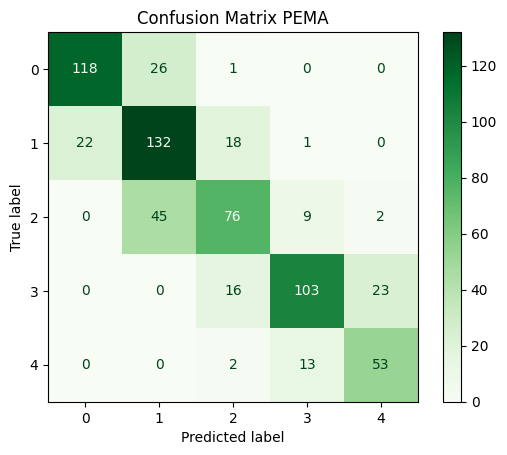

In [110]:
#create confusion matrix for outputs
cm = confusion_matrix(Y_test.numpy(), test_preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix PEMA")

plt.savefig("supervised plots/PEMA confusion matrix.png")
plt.show()

In [111]:
#produce precision, recall and f1 scores for each bin
print(classification_report(Y_test.numpy(), test_preds.numpy()))

              precision    recall  f1-score   support

           0       0.84      0.81      0.83       145
           1       0.65      0.76      0.70       173
           2       0.67      0.58      0.62       132
           3       0.82      0.73      0.77       142
           4       0.68      0.78      0.73        68

    accuracy                           0.73       660
   macro avg       0.73      0.73      0.73       660
weighted avg       0.74      0.73      0.73       660



In [112]:
accuracy_differences = permutation_importance(model, X_test, Y_test)

for f, acc_d in zip(features, accuracy_differences):
    print(f, acc_d)

wind_u 0.02121216058731079
wind_v 0.050000011920928955
pm_lag6 0.02272731065750122
pm_lag3 0.0
pm_lag2 0.12424242496490479
pm_lag1 0.5060606002807617
hour_sin -0.0015151500701904297
hour_cos 0.0030303001403808594
rh 0.0015151500701904297


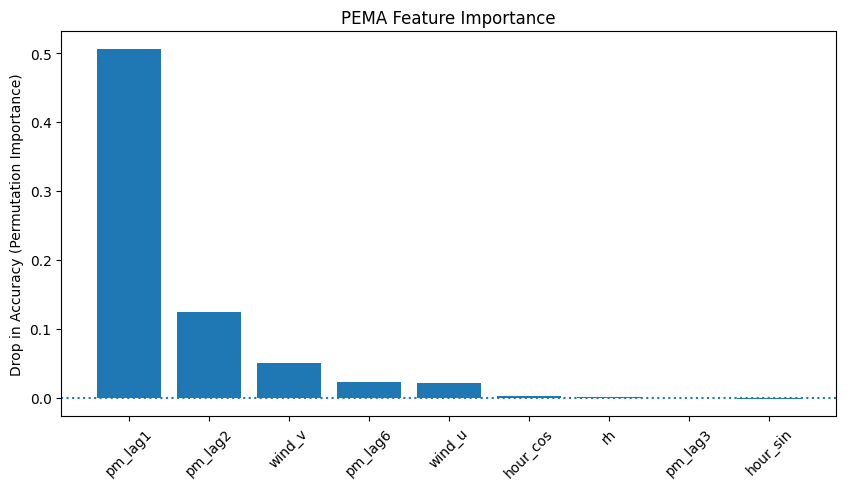

In [113]:
#plot feature importance
importance_dict = dict(zip(features, accuracy_differences))
sorted_items = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("PEMA Feature Importance")

plt.axhline(y=0, linestyle=":")

plt.savefig("supervised plots/PEMA feature importance full.png")
plt.show()

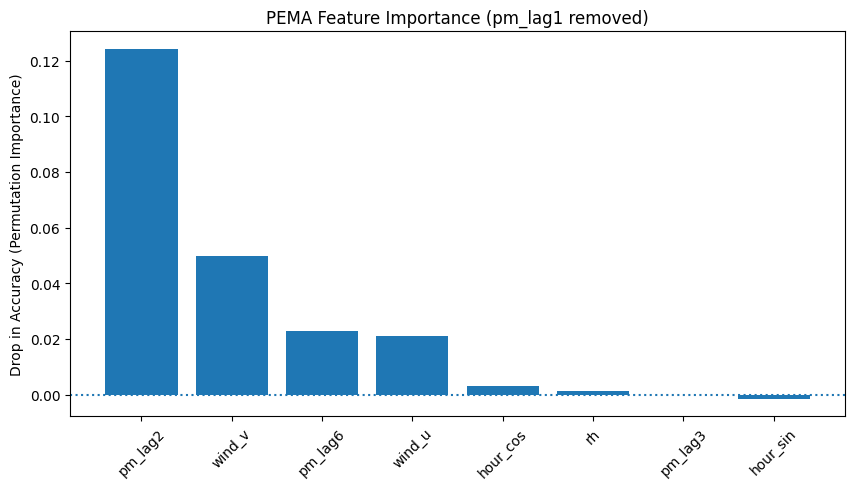

In [114]:
importance_dict = dict(zip(features, accuracy_differences))
#remove pm_lag1 to see other features better
sorted_items = sorted([(f, v) for f, v in importance_dict.items() if f != "pm_lag1"], key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("PEMA Feature Importance (pm_lag1 removed)")

plt.axhline(y=0, linestyle=":")

plt.savefig("supervised plots/PEMA feature importance pm_lag1 removed.png")
plt.show()

## PHA Supervised Learning

In [115]:
pha_final = pd.read_csv("final PM data/pha_final_pm25.csv")
pha_final = pha_final.sort_values("datetime_utc").reset_index(drop=True)
pha_final.head()

,datetime_utc,rh,temp,wd,ws,pm25,wind_u,wind_v,hour,hour_sin,hour_cos,pm_lag1,pm_lag2,pm_lag3,pm_lag6,pm25_bin
0,2025-01-02 06:00:00+00:00,62.023333,3.330000,261.698333,2.648500,0.207967,2.620748,0.382404,6,1.000000,6.123234e-17,0.165667,0.168467,0.198267,0.389583,0
1,2025-01-02 07:00:00+00:00,58.768333,3.020000,270.975000,2.878667,0.295167,2.878250,-0.048984,7,0.965926,-2.588190e-01,0.207967,0.165667,0.168467,0.214200,0
2,2025-01-02 08:00:00+00:00,55.421667,2.898333,273.275000,2.903833,0.309267,2.899091,-0.165891,8,0.866025,-5.000000e-01,0.295167,0.207967,0.165667,0.192533,0
3,2025-01-02 09:00:00+00:00,53.240000,2.845000,273.426667,2.866000,0.312800,2.860876,-0.171304,9,0.707107,-7.071068e-01,0.309267,0.295167,0.207967,0.198267,0
4,2025-01-02 10:00:00+00:00,52.566667,2.850000,266.546667,2.758667,0.346200,2.753657,0.166170,10,0.500000,-8.660254e-01,0.312800,0.309267,0.295167,0.168467,0


In [116]:
#define 7 hour gap so as to not "leak" data between train/validation/testing
gap = 7
n = len(dpw_final)

#we segment full time series data into train/valid/test sets quarterly with proper gaps
#allows proper spread of data so that train/valid/test are not limited to certain areas in the time series
train_size = int(.15 * n)
val_size = int(.05 * n)
test_size = int(.05 * n)

#lists of dataframes
train_dfs = []
val_dfs = []
test_dfs = []
start = 0

#loop through data 4 times
for i in range(4):
    train_start = start
    train_end = train_start + train_size

    val_start = train_end + gap
    val_end = val_start + val_size

    test_start = val_end + gap
    test_end = test_start + test_size

    #break loop if out of data
    if test_end > n:
        break

    #add dataframes to list
    train_dfs.append(pha_final.iloc[train_start:train_end])
    val_dfs.append(pha_final.iloc[val_start:val_end])
    test_dfs.append(pha_final.iloc[test_start:test_end])

    #define new "start"
    start = test_end + gap

#concatenate full dataframe
train_df = pd.concat(train_dfs)
val_df = pd.concat(val_dfs)
test_df = pd.concat(test_dfs)

features = [
    "wind_u", "wind_v",
    "pm_lag6", "pm_lag3", "pm_lag2", "pm_lag1",
    "hour_sin", "hour_cos",
    "rh"
]

#define train, test, validation arrays
X_train = train_df[features].values
Y_train = train_df["pm25_bin"].values

X_val = val_df[features].values
Y_val = val_df["pm25_bin"].values

X_test = test_df[features].values
Y_test = test_df["pm25_bin"].values

#create tensor objects
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_val = torch.tensor(Y_val, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

In [117]:
input_dim = len(features)

#define neural network
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 5)
        )
    
    def forward(self, x):
        return self.model(x)

model = NN()

#utilize cross entropy loss here
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = .001)

In [118]:
#epochs based on observation of validation accuracy
epochs = 1000

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = loss_function(outputs, Y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    #calculate validation accuracy
    with torch.no_grad():
        val_outputs = model(X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = (val_predictions == Y_val).float().mean()

    #print to check validation accuracy
    if (epoch) % 100 == 0:
        epoch_s = "Epoch: " + str(epoch) + " "
        loss_s = "Loss: " + str(loss.item()) + " "
        valid_s = "Validation Accuracy: " + str(float(val_accuracy))
        print(epoch_s + loss_s + valid_s)

Epoch: 0 Loss: 2.4962007999420166 Validation Accuracy: 0.25338754057884216
Epoch: 100 Loss: 1.1746673583984375 Validation Accuracy: 0.4525745213031769
Epoch: 200 Loss: 0.9127622246742249 Validation Accuracy: 0.575880765914917
Epoch: 300 Loss: 0.7661752104759216 Validation Accuracy: 0.6531165242195129
Epoch: 400 Loss: 0.6601987481117249 Validation Accuracy: 0.705962061882019
Epoch: 500 Loss: 0.590475857257843 Validation Accuracy: 0.7303522825241089
Epoch: 600 Loss: 0.5497419238090515 Validation Accuracy: 0.7493224740028381
Epoch: 700 Loss: 0.5232712626457214 Validation Accuracy: 0.7642276287078857
Epoch: 800 Loss: 0.5060110092163086 Validation Accuracy: 0.7655826807022095
Epoch: 900 Loss: 0.49361923336982727 Validation Accuracy: 0.772357702255249


In [119]:
test_outputs = model(X_test)
#select bin with highest probability
test_preds = torch.argmax(test_outputs, dim=1)

test_acc = (test_preds == Y_test).float().mean()
print("Final Test Accuracy " + str(test_acc.item()))

Final Test Accuracy 0.7872628569602966


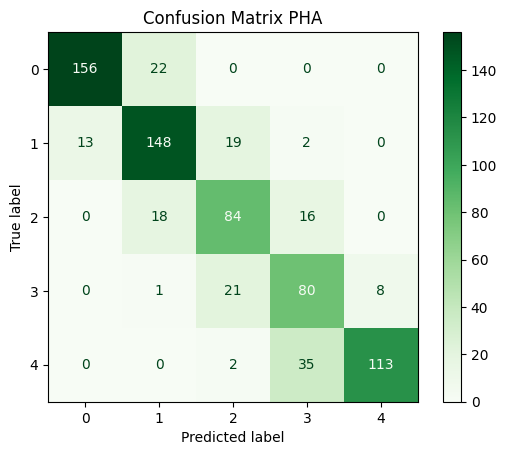

In [120]:
#create confusion matrix for outputs
cm = confusion_matrix(Y_test.numpy(), test_preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3,4])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix PHA")

plt.savefig("supervised plots/PHA confusion matrix.png")
plt.show()

In [121]:
#produce precision, recall and f1 scores for each bin
print(classification_report(Y_test.numpy(), test_preds.numpy()))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       178
           1       0.78      0.81      0.80       182
           2       0.67      0.71      0.69       118
           3       0.60      0.73      0.66       110
           4       0.93      0.75      0.83       150

    accuracy                           0.79       738
   macro avg       0.78      0.78      0.78       738
weighted avg       0.80      0.79      0.79       738



In [122]:
accuracy_differences = permutation_importance(model, X_test, Y_test)

for f, acc_d in zip(features, accuracy_differences):
    print(f, acc_d)

wind_u 0.059620559215545654
wind_v 0.04878050088882446
pm_lag6 0.0257452130317688
pm_lag3 0.09756094217300415
pm_lag2 0.07723575830459595
pm_lag1 0.5677506923675537
hour_sin 0.00270998477935791
hour_cos 0.004065036773681641
rh 0.052845537662506104


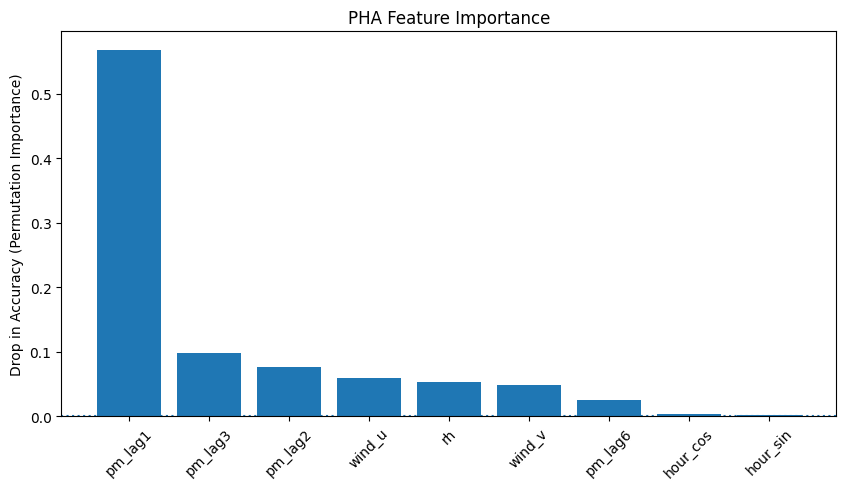

In [123]:
#plot importance values on bar chart
importance_dict = dict(zip(features, accuracy_differences))
sorted_items = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("PHA Feature Importance")

plt.axhline(y=0, linestyle=":")

plt.savefig("supervised plots/PHA feature importance full.png")
plt.show()

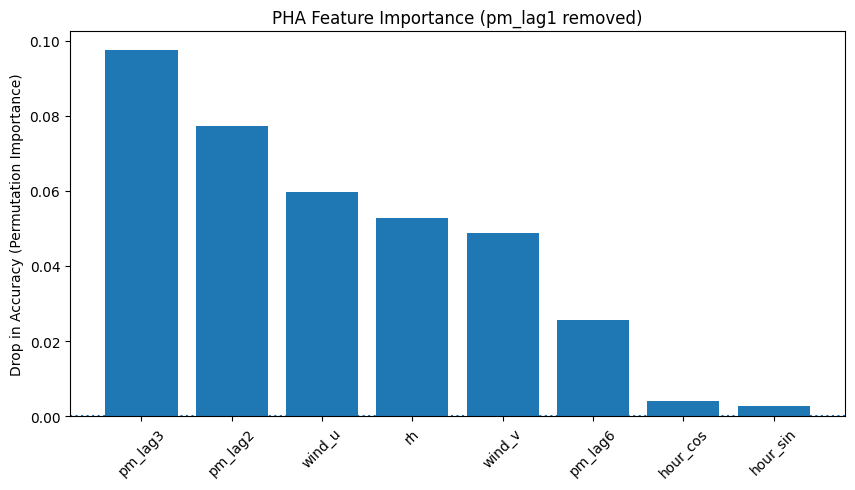

In [124]:
importance_dict = dict(zip(features, accuracy_differences))
#remove pm_lag1 to see other features better
sorted_items = sorted([(f, v) for f, v in importance_dict.items() if f != "pm_lag1"], key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

plt.figure(figsize=(10, 5))
plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Drop in Accuracy (Permutation Importance)")
plt.title("PHA Feature Importance (pm_lag1 removed)")

plt.axhline(y=0, linestyle=":")

plt.savefig("supervised plots/PHA feature importance pm_lag1 removed.png")
plt.show()